# Lab 2. Przetwarzanie danych w Sparku

Spark nie ładuje wszystkiego do RAMu i stosuje podejście `lazy`, czyli tworzy plan wykonania operacji i ją wykonuje tylko i wyłacznie wtedy kiedy to niezbędne

__RDD - Resilient Distributed Dataset__
- bazowa struktura danych w open-source-owym środowisku przetwarzania danych Apache Spark
- wymaga znajomości MapReduce
- nie jest to df
- wymaga funkcji lambda

__MapReduce__
Model przetwarzania danych oparty na dwóch etapach:
- **Map** — przekształcanie danych wejściowych do par klucz-wartość
- **Reduce** — agregacja wyników dla tych samych kluczy

W Spark idea jest podobna, ale operacje są wykonywane wygodniej na RDD lub DataFrame, np. przez `groupBy`, `agg`, `sum`, `count`.

__SparkDataFrame__ <br>
PySpark - pythonowe api do Sparka <br>
SparkDataFrame jest używany wtedy kiedy dane są zbyt duże i nie mieszczą się w pandas.DataFrame

Polars jest alternatywą dla Sparka i Pandas, składnia prawie identyczna do PySparka

W tym labie:
1. Tworzymy nowy folder
2. Clonujemy: git clone https://github.com/sebkaz-teaching/cwiczenia.git
3. Pracujemy w podejściu wsadowym (za tydzien strumieniowe)


## 1. Import, utworzenie sesji sparkowej, wczytanie danych 

In [1]:
from pyspark.sql import SparkSession
# Jeżeli gdzielowiek widać .sql to znaczy że korzystamy z nowego sparka
# SparkContext - stary Spark

In [2]:
spark = (
    SparkSession.builder
    .appName("Lab2-Transactions")
    .getOrCreate()                  # Zabezpieczenie przed istniejącą sesją w naszym kernelu
)
spark.sparkContext.setLogLevel("WARN")  # Stary spark pozwala poziom logowania na warning
print(f"Spark {spark.version} - gotowy")

Spark 4.0.0-preview2 - gotowy


In [3]:
sc = spark.sparkContext

Sesja sparka:
- można mieć aktywną tylko jedną sesje sparka w kernelu

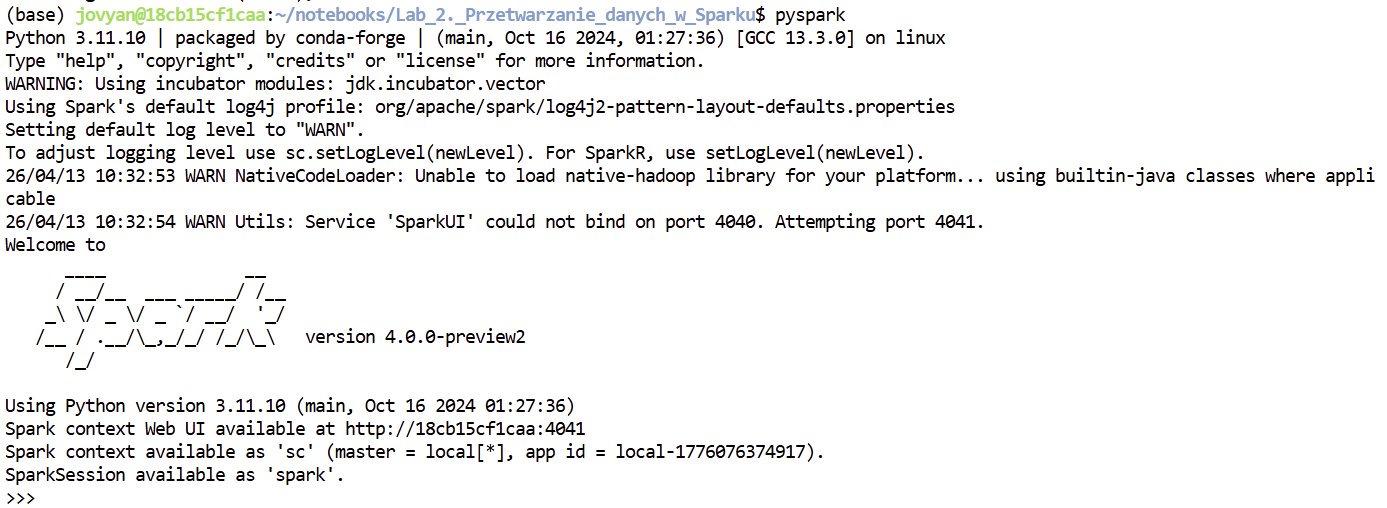

In [7]:
df = spark.read.json("transactions_10k.jsonl")
print(f"Liczba rekordów: {df.count()}")
df.printSchema()

Liczba rekordów: 10000
root
 |-- amount: double (nullable = true)
 |-- category: string (nullable = true)
 |-- store: string (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- tx_id: string (nullable = true)
 |-- user_id: string (nullable = true)



In [8]:
# Zmieniamy typ danych zmiennej timestamp
from pyspark.sql.functions import to_timestamp, col

# to_timestamp() - funkcja do zamiany typu zmiennej na timestamp
# col() - funkcja - pozwalająca wybrać kolumnę

df = df.withColumn("timestamp", to_timestamp(col("timestamp"), "yyyy-MM-dd HH:mm:ss"))

# df.withColumn() - tworzenie/dodawanie nowej kolumnhy do dataframe

df.printSchema()

root
 |-- amount: double (nullable = true)
 |-- category: string (nullable = true)
 |-- store: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- tx_id: string (nullable = true)
 |-- user_id: string (nullable = true)



## Zad 2.1 Liczba transakcji i suma przychodów per sklep

Tworzymy agregaty po zmiennych kategorycznych

In [9]:
from pyspark.sql.functions import count, sum as _sum, avg, round as _round

store_summary= (
    df.groupBy("store")
    .agg(
        count("tx_id").alias("liczba_tx"),
        _round(_sum("amount"), 2).alias("suma_PLN"),
        _round(avg("amount"), 2).alias("srednia_PLN"),
    )
    .orderBy("store")
)

Kod się jeszcze nie wykonał, tylko siedzi w Sparku.

In [19]:
store_summary.show()

+--------+---------+----------+-----------+
|   store|liczba_tx|  suma_PLN|srednia_PLN|
+--------+---------+----------+-----------+
|  Gdańsk|     2498|1021266.35|     408.83|
|  Kraków|     2522|1025896.95|     406.78|
|Warszawa|     2424| 961642.24|     396.72|
| Wrocław|     2556|1002739.21|     392.31|
+--------+---------+----------+-----------+



Teraz kod się wykonał.

## Zad 2.2 Statystyki per kategoria

In [10]:
from pyspark.sql.functions import min as _min, max as _max

category_stats = (
    df.groupBy("category")
    .agg(
        _round(_sum("amount"), 2).alias("suma_PLN"),
        _round(_min("amount"), 2).alias("min_PLN"),
        _round(_max("amount"), 2).alias("max_PLN"),
    )
    .orderBy("category")
)

category_stats.show()

+-----------+----------+-------+-------+
|   category|  suma_PLN|min_PLN|max_PLN|
+-----------+----------+-------+-------+
|elektronika|1520770.69|    9.0| 9999.0|
|    książki| 851382.08|    5.0|9107.25|
|     odzież| 849877.55|    5.0|9696.63|
|    żywność| 789514.43|    5.0|6916.92|
+-----------+----------+-------+-------+



## Zadanie 3.1

In [12]:
from pyspark.sql.functions import window

In [13]:
hourly = (
    df.groupBy(window("timestamp", "1 hour"))    # okno 1-godzinne
    .agg(
        count("tx_id").alias("liczba_tx"),
        _round(_sum("amount"), 2).alias("suma_PLN"),
    )
    .orderBy("window")
)
hourly.show(truncate=False)

+------------------------------------------+---------+----------+
|window                                    |liczba_tx|suma_PLN  |
+------------------------------------------+---------+----------+
|{2026-04-12 08:00:00, 2026-04-12 09:00:00}|3150     |1241911.3 |
|{2026-04-12 09:00:00, 2026-04-12 10:00:00}|4661     |1896230.21|
|{2026-04-12 10:00:00, 2026-04-12 11:00:00}|2189     |873403.24 |
+------------------------------------------+---------+----------+



In [14]:
hourly.printSchema()

root
 |-- window: struct (nullable = false)
 |    |-- start: timestamp (nullable = true)
 |    |-- end: timestamp (nullable = true)
 |-- liczba_tx: long (nullable = false)
 |-- suma_PLN: double (nullable = true)



struct zawiera inne elementy (kolumny wewnątrz innej kolumny)

In [15]:
(
    hourly
    .select(
        col("window.start").alias("od"),
        col("window.end").alias("do"),
        "liczba_tx",
        "suma_PLN",
    )
    .show(truncate=False)
)

+-------------------+-------------------+---------+----------+
|od                 |do                 |liczba_tx|suma_PLN  |
+-------------------+-------------------+---------+----------+
|2026-04-12 08:00:00|2026-04-12 09:00:00|3150     |1241911.3 |
|2026-04-12 09:00:00|2026-04-12 10:00:00|4661     |1896230.21|
|2026-04-12 10:00:00|2026-04-12 11:00:00|2189     |873403.24 |
+-------------------+-------------------+---------+----------+



## Zad 3.2 Liczba transakcji per godzina (tumbling 1h)

In [16]:
window_30m_store = (
    df.groupBy(window("timestamp", "30 minutes"), "store")
    .agg(
        count("tx_id").alias("liczba_tx"),
        _round(_sum("amount"), 2).alias("suma_PLN"),
    )
    .select(
        col("window.start").alias("od"),
        col("window.end").alias("do"),
        "store",
        "liczba_tx",
        "suma_PLN",
    )
    .orderBy("od", "store")
)

window_30m_store.show(truncate=False)

+-------------------+-------------------+--------+---------+---------+
|od                 |do                 |store   |liczba_tx|suma_PLN |
+-------------------+-------------------+--------+---------+---------+
|2026-04-12 08:00:00|2026-04-12 08:30:00|Gdańsk  |252      |93391.22 |
|2026-04-12 08:00:00|2026-04-12 08:30:00|Kraków  |289      |117786.42|
|2026-04-12 08:00:00|2026-04-12 08:30:00|Warszawa|275      |88441.58 |
|2026-04-12 08:00:00|2026-04-12 08:30:00|Wrocław |296      |111540.59|
|2026-04-12 08:30:00|2026-04-12 09:00:00|Gdańsk  |514      |209187.85|
|2026-04-12 08:30:00|2026-04-12 09:00:00|Kraków  |532      |223541.41|
|2026-04-12 08:30:00|2026-04-12 09:00:00|Warszawa|490      |182435.06|
|2026-04-12 08:30:00|2026-04-12 09:00:00|Wrocław |502      |215587.17|
|2026-04-12 09:00:00|2026-04-12 09:30:00|Gdańsk  |619      |253364.95|
|2026-04-12 09:00:00|2026-04-12 09:30:00|Kraków  |590      |224358.03|
|2026-04-12 09:00:00|2026-04-12 09:30:00|Warszawa|584      |214573.66|
|2026-

## Zad 3.3 W której godzinie sklep “Kraków” miał najwyższy przychód?

In [17]:
krakow_best_hour = (
    df.filter(col("store") == "Kraków")
    .groupBy(window("timestamp", "1 hour"))
    .agg(_round(_sum("amount"), 2).alias("suma_PLN"))
    .select(
        col("window.start").alias("od"),
        col("window.end").alias("do"),
        "suma_PLN"
    )
    .orderBy(col("suma_PLN").desc())
)

krakow_best_hour.show(1, truncate=False)

+-------------------+-------------------+---------+
|od                 |do                 |suma_PLN |
+-------------------+-------------------+---------+
|2026-04-12 09:00:00|2026-04-12 10:00:00|483309.86|
+-------------------+-------------------+---------+
only showing top 1 row



## Zad 4.1 Okno 1h, krok 30 minut
Okno Sliding

In [29]:
sliding = (
    df.groupBy(window("timestamp", "1 hour", "30 minutes"))  # szerokość 1h, krok 30min
    .agg(
        count("tx_id").alias("liczba_tx"),
        _round(_sum("amount"), 2).alias("suma_PLN"),
    )
    .select(
        col("window.start").alias("od"),
        col("window.end").alias("do"),
        "liczba_tx",
        "suma_PLN",
    )
    .orderBy("od")
)
sliding.show(truncate=False)

+-------------------+-------------------+---------+----------+
|od                 |do                 |liczba_tx|suma_PLN  |
+-------------------+-------------------+---------+----------+
|2026-04-12 07:30:00|2026-04-12 08:30:00|1112     |411159.81 |
|2026-04-12 08:00:00|2026-04-12 09:00:00|3150     |1241911.3 |
|2026-04-12 08:30:00|2026-04-12 09:30:00|4443     |1753033.6 |
|2026-04-12 09:00:00|2026-04-12 10:00:00|4661     |1896230.21|
|2026-04-12 09:30:00|2026-04-12 10:30:00|3696     |1557641.39|
|2026-04-12 10:00:00|2026-04-12 11:00:00|2189     |873403.24 |
|2026-04-12 10:30:00|2026-04-12 11:30:00|749      |289709.95 |
+-------------------+-------------------+---------+----------+



## Zad 4.2 Porównaj tumbling vs sliding

In [18]:
tumbling_rows = (
    df.groupBy(window("timestamp", "1 hour"))
    .agg(count("tx_id"))
    .count()
)

sliding_rows = (
    df.groupBy(window("timestamp", "1 hour", "30 minutes"))
    .agg(count("tx_id"))
    .count()
)

print(f"Tumbling (1h):          {tumbling_rows} okien")
print(f"Sliding  (1h / 30min):  {sliding_rows} okien")

# Odpowiedz w komentarzu: dlaczego sliding ma więcej wierszy?
# TWOJA ODPOWIEDŹ:

Tumbling (1h):          3 okien
Sliding  (1h / 30min):  7 okien


Sliding daje więcej wierszy, ponieważ okna nakładają się na siebie.
Przy tumbling każde zdarzenie trafia tylko do jednego okna, a przy sliding to samo zdarzenie może trafić do kilku okien.

## Zad 5. Pytania kontrolne

### 1. Ile transakcji jest w oknie 09:00–10:00?
   4661
   - 09:00–09:30: 619 + 590 + 584 + 612 = 2405
   - 09:30–10:00: 555 + 579 + 533 + 589 = 2256
   - 2405 + 2256 = 4661

### 2. Jaka jest różnica między groupBy("store") a groupBy(window(...), "store")?
   groupBy("store") agreguje wszystkie transakcje tylko według sklepu,
   bez uwzględniania czasu. groupBy(window(...), "store") agreguje dane jednocześnie
   według przedziału czasu i sklepu, więc dostajemy osobne wyniki dla każdego sklepu
   w każdym oknie czasowym.

### 3. W oknie sliding 1h/30min — ile okien zawiera transakcje z godziny 09:30?
   2 okna — 09:00–10:00 oraz 09:30–10:30.

## Praca domowa

### 1. Znajdź godzinę, w której sklep Gdańsk miał najniższą średnią kwotę transakcji.

In [29]:
from pyspark.sql.functions import avg

gdansk_lowest_avg = (
    df.filter(col("store") == "Gdańsk")
    .groupBy(window("timestamp", "1 hour"))
    .agg(_round(avg("amount"), 2).alias("srednia_PLN"))
    .select(
        col("window.start").alias("od"),
        col("window.end").alias("do"),
        "srednia_PLN"
    )
    .orderBy("srednia_PLN")
)

gdansk_lowest_avg.show(1, truncate=False)

+-------------------+-------------------+-----------+
|od                 |do                 |srednia_PLN|
+-------------------+-------------------+-----------+
|2026-04-12 08:00:00|2026-04-12 09:00:00|395.01     |
+-------------------+-------------------+-----------+
only showing top 1 row



### 2. Policz ile transakcji per kategoria było w oknie 09:00–09:30.

In [28]:
category_0900_0930 = (
    df.filter(
        (col("timestamp") >= "2026-04-12 09:00:00") &
        (col("timestamp") <  "2026-04-12 09:30:00")
    )
    .groupBy("category")
    .agg(count("tx_id").alias("liczba_tx"))
    .orderBy("category")
)

category_0900_0930.show()

+-----------+---------+
|   category|liczba_tx|
+-----------+---------+
|elektronika|      611|
|    książki|      622|
|     odzież|      605|
|    żywność|      567|
+-----------+---------+



### 3. Zrób okno 15-minutowe i sprawdź w której ćwierćgodzinie był szczyt transakcji (łącznie dla wszystkich sklepów).

In [27]:
peak_15m = (
    df.groupBy(window("timestamp", "15 minutes"))
    .agg(count("tx_id").alias("liczba_tx"))
    .select(
        col("window.start").alias("od"),
        col("window.end").alias("do"),
        "liczba_tx"
    )
    .orderBy(col("liczba_tx").desc())
)

peak_15m.show(1, truncate=False)

+-------------------+-------------------+---------+
|od                 |do                 |liczba_tx|
+-------------------+-------------------+---------+
|2026-04-12 09:15:00|2026-04-12 09:30:00|1234     |
+-------------------+-------------------+---------+
only showing top 1 row

